# Test the "Buy-And-Hold" Trading Strategy

This interactive nootebook tests the "buy-and-hold" trading strategy and provides some plots for data anlysis.

## Import Packages

In [1]:
from tradelab import *
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import math

## Define and Execute Trading Strategy

Define key parameters

In [2]:
ticker = ["AAPL"]
qty = 1

start_time = "2010-01-01"
end_time = "2026-01-01"

Compute how much cash is needed to execute strategy.

In [3]:
cash = math.ceil(
    float(
        yf.download(
            ticker[0],
            start=start_time,
            end=pd.Timestamp(start_time) + pd.Timedelta("14D"),
            auto_adjust=False,
            progress=False)
            ['Adj Close'][ticker[0]].max()))

print(cash)

7


Create data handler, portfolio, strategy and trading engine.

In [4]:
data_handler = YFinanceDataHandler(
    tickers=ticker,
    start_time=start_time,
    end_time=end_time)

portfolio = Portfolio(deposit=cash)

strategy = BuyAndHold(
    ticker=ticker[0],
    quantity=qty,
    start_time=start_time,
    end_time=end_time,
    offset="7D"
)

engine = TradingEngine(
    portfolio = portfolio,
    strategy = strategy,
    data_handler = data_handler
)

[*********************100%***********************]  1 of 1 completed


Run backtest

In [5]:
history = engine.run_backtest()

Backtesting complete


## Visualize Performance

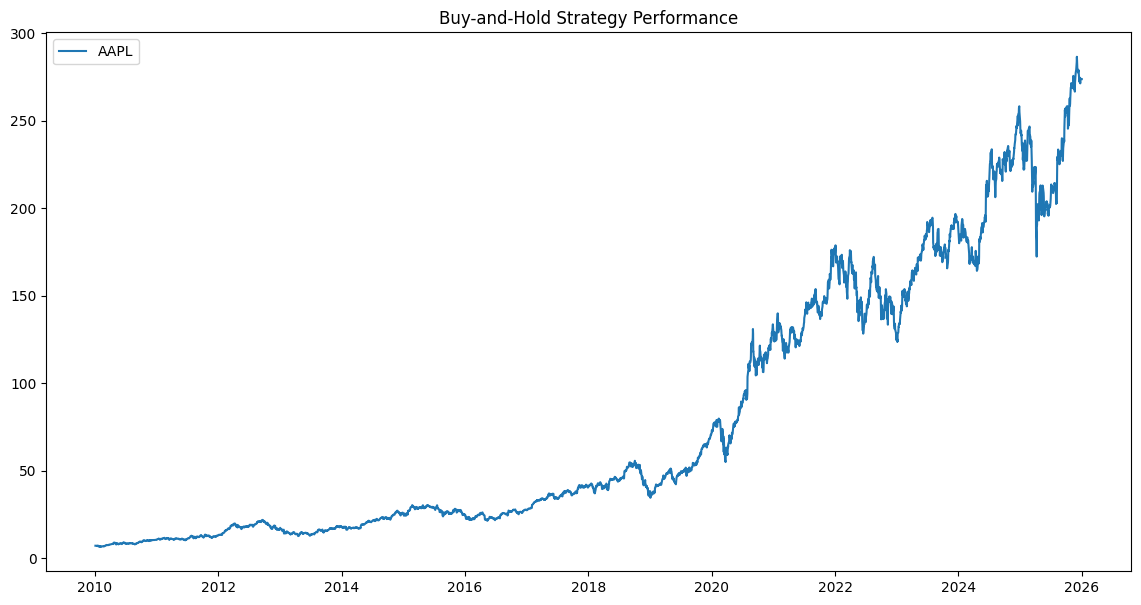

In [6]:
x, y = zip(*((h['timestamp'], h['total_value']) for h in history))

plt.figure(figsize=(14, 7))
plt.plot(x,y, label=f"{ticker[0]}")
plt.title("Buy-and-Hold Strategy Performance")
plt.legend()
plt.show()

Evaluate Performance

In [7]:
print(f"Total Strategy Return: {y[-1]/y[0]:.2%}")

Total Strategy Return: 3911.33%


## License

This file is part of TradeLab.

Copyright © 2026 Hannes Malcha

TradeLab is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

TradeLab is distributed in the hope that it will be useful, 
but WITHOUT ANY WARRANTY; without even the implied warranty of 
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the 
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with TradeLab. If not, see https://www.gnu.org/licenses/.